In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

import locale, matplotlib
locale.setlocale(locale.LC_ALL, 'ru_RU')
matplotlib.rcParams['axes.formatter.use_locale'] = True

from utils import load_saved_path
from plots import plot_theta_background

In [2]:
theta1, y1, t1, theta_est1, y_est1, observations1 = load_saved_path("example_for_arc3_0.5")
theta2, y2, t2, theta_est2, y_est2, observations2 = load_saved_path("example_for_arc3_0.1")
theta3, y3, t3, theta_est3, y_est3, observations3 = load_saved_path("example_for_arc3_0.01")
theta4, y4, t4, theta_est4, y_est4, observations4 = load_saved_path("example_for_arc3_0.001")

In [3]:
theta_labels = ['$\\theta_t = e_1$', '$\\theta_t = e_2$']

theta_colors = ['chocolate', 'k']

abc = ['а', 'б', 'в', 'г']

M = 2

In [4]:
def plot_theta(theta, t, theta_opt_list, t_nets, abc=abc):

    fig, ax = plt.subplots(figsize=((1 + np.sqrt(5))/2 * 8, 4), layout='constrained')

    hts = [t_net[1] - t_net[0] for t_net in t_nets]

    est_lines = []
    line1, = ax.step(
        [0] + list(t), 
        [(theta[0] == 0)] + list(theta == 0), 
        lw=1.5,
        color='k'
    )
    for t_net, theta_opt in zip(t_nets, theta_opt_list):
        line4, = ax.plot(t_net, theta_opt[:, 0],
                            #color='red', 
                            lw=1)
        est_lines.append(line4)

    ax.set(
        xlim=(0, 10),
        ylim=(-0.1, 1.1)
    )
    #ax.set_xlabel('({})'.format(abc[]), fontsize=13)
    ax.set_ylabel('$\\theta_t^1$', fontsize=14, rotation='horizontal')
    ax.yaxis.set_label_coords(-0.03, 0.4)
    ax.tick_params(labelsize=14)
    ax.set_xticks(
        [0, 2, 4, 6, 8, 10], 
        ['0', '2', '4', '6', '8', '$t$']
    )
    ax.set_yticks(ticks=[0, 1])
    ax.spines["bottom"].set_color("k")
    ax.spines["top"].set_color("k")
    ax.spines["left"].set_color("k")
    ax.spines["right"].set_color("k")

    fig.legend(
        fontsize=16,
        handles=[line1] + est_lines,
        labels=['$\\theta_t^i$'] + [
            f'$\\overline{{\\theta}}_t^1$ при $\\Delta_t = {{{str(ht).replace('.', ',')}}}$' for ht in hts
        ],
        loc='outside lower center',
        ncol=5,
        framealpha=1,
        frameon=False
    )

    return fig, ax



In [5]:
from math import ceil

t_nets = [
    np.array([i*step for i in range(ceil(10 / step)+1)])
    for step in [0.5, 0.1, 0.01, 0.001,]
]
# 0.01

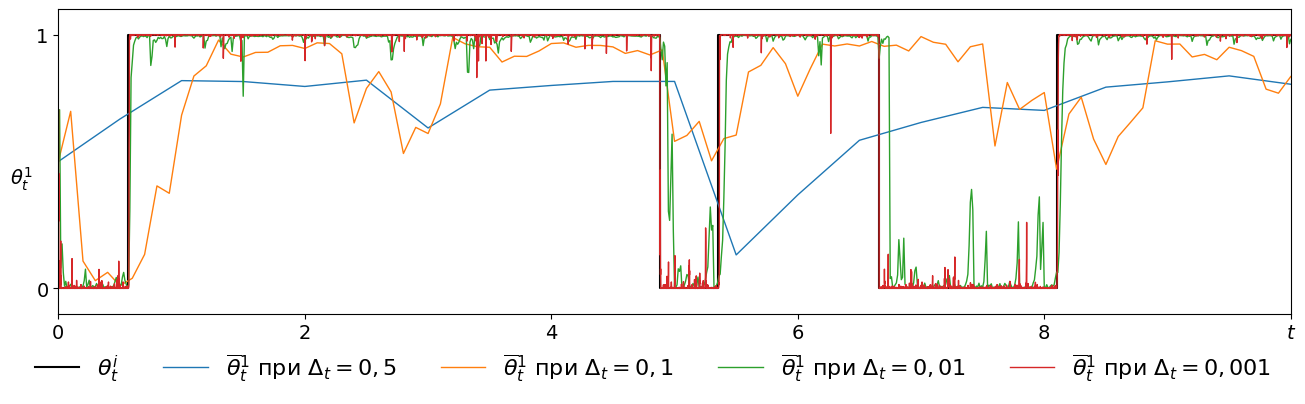

In [6]:
#theta_est3[:1001],

fig, ax = plot_theta(theta1, t1, [theta_est1, theta_est2, theta_est3, theta_est4], t_nets)

plt.show()

In [7]:
def plot_y(
    theta, y, t, y_opt_list, t_nets,
    abc=abc, 
    theta_labels=theta_labels, 
    theta_colors=theta_colors
):
    fig, ax = plt.subplots(M, figsize=(16, 8), layout='constrained')

    labels = []

    
    est_lines = []
    for t_net, y_opt in zip(t_nets, y_opt_list):
        line2, = ax[0].plot(
            t_net, y_opt[:, 0],
            #color='red', lw=1.2
        )
        line4, = ax[1].plot(
            t_net, y_opt[:, 1],
            #color='green', lw=1.2,
        )
        est_lines.append(line2)
    
    

    for m in range(M):
        line1, = ax[m].step( 
            [0] + list(t),
            [y[0, m]] + list(y[:, m]),
            where='pre', lw=2, color='k', 
        )
        
        
        ax[m].set_ylabel('$Y^{}_t$'.format(m+1), fontsize=16, rotation='horizontal')
        ax[m].yaxis.set_label_coords(-0.05, 0.45)

        ax[m].set_xlim(0, 10)
        ax[m].set_xlabel(f'({abc[m]})', fontsize=16)
        ax[m].set_xticks(
            [0, 2, 4, 6, 8, 10], 
            ['0', '2', '4', '6', '8', '$t$'],
        )
        ax[m].set_frame_on(True)
        ax[m].spines["bottom"].set_color("k")
        ax[m].spines["top"].set_color("k")
        ax[m].spines["left"].set_color("k")
        ax[m].spines["right"].set_color("k")
        ax[m].tick_params(labelsize=14)

        theta_lines = plot_theta_background(
            ax[m], theta, t, theta_labels, theta_colors, 10, alpha=0.3,
        )

    #ax[0].set_ylim(0.015, 0.065)
    #ax[0].set_yticks([0.02, 0.04, 0.06], ['0,02', '0,04', '0,06'])
    #ax[1].set_ylim(0.00, 0.11)
    #ax[1].set_yticks([0.01, 0.04, 0.07, 0.1], ['0,01', '0,04', '0,07', '0,10'])
    
    labels = theta_labels + ['$Y_t^i$'] + [
        f'$\\overline{{Y}}_t^i$ при $\\Delta_t = {{{str(t_net[1] - t_net[0]).replace('.', ',')}}}$'\
            for t_net in t_nets
    ]

    handles = theta_lines + [line1] + est_lines


    fig.legend(
        fontsize=18,
        handles=handles,
        labels=labels,
        loc='outside lower center',
        ncol=len(labels),
        frameon=False,
        #framealpha=1,
        #facecolor='gainsboro'
    )

    fig.align_ylabels()

    return fig, ax


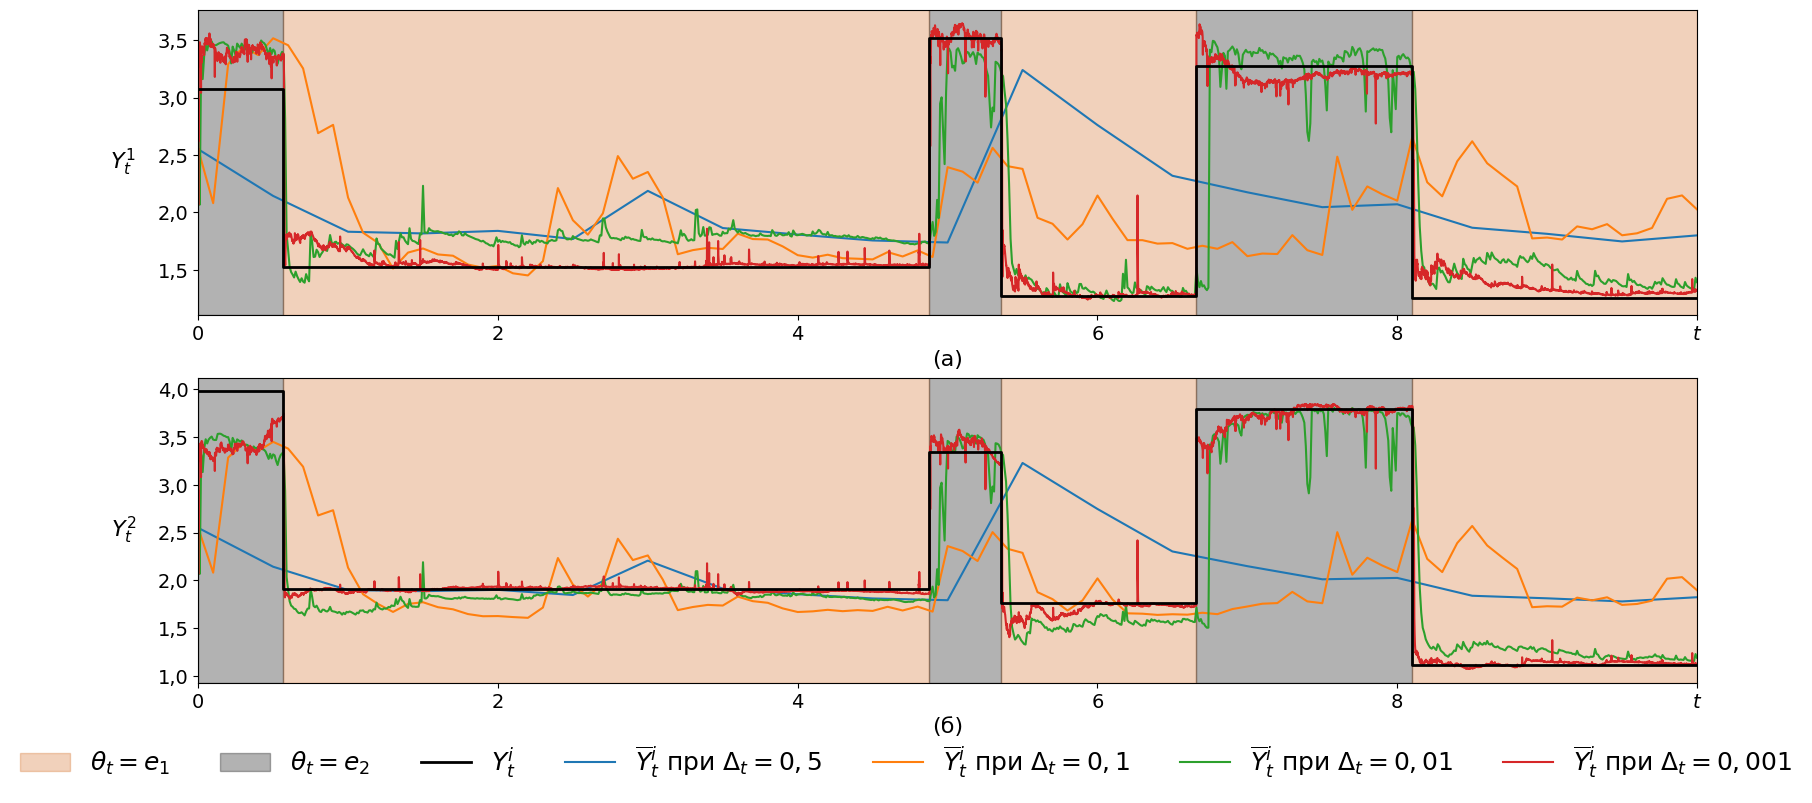

In [8]:
fig, axs = plot_y(theta1, y1, t1, [y_est1, y_est2, y_est3,  y_est4], t_nets)

# y_est3[:1001],